In [4]:
from pathlib import Path

MODEL_DIR = Path("../models")

In [5]:
from graphies.predict.models import GRU
from graphies.predict import GraphiesModel, GraphiesTokenizer

tokenizer = GraphiesTokenizer(MODEL_DIR / "selfies-data/selfies.json")
model = GraphiesModel.from_checkpoint(
    checkpoint=MODEL_DIR / "selfies-data/model.pt",
    tokenizer=tokenizer,
    model_cls=GRU,
    device="cuda",
)

In [6]:
from datasets import load_dataset

hf_dataset = load_dataset("lukaskim/ChEMBL-36", "molecules", split="train")

In [7]:
ref = hf_dataset.shuffle(seed=42).select(range(10_000))
ref_smiles = ref["canonical_smiles"]

In [8]:
import selfies as sf

gen_smiles = [
    sf.decoder(tokenizer.strip(smi))
    for _ in range(10)
    for smi in model.generate(num=1024, temperature=1.0, top_p=1, max_len=200)
]

In [9]:
from collections import defaultdict
from rdkit import Chem
from rdkit.Chem import QED
from rdkit.Chem import rdMolDescriptors

def compute_stats(smiles: list[str]) -> dict:
    output = defaultdict(list)

    for smi in smiles:
        mol = Chem.MolFromSmiles(smi)
        
        output['mw'].append(rdMolDescriptors.CalcExactMolWt(mol))
        output['hba'].append(rdMolDescriptors.CalcNumHBA(mol))
        output['hbd'].append(rdMolDescriptors.CalcNumHBD(mol))
        output['tpsa'].append(rdMolDescriptors.CalcTPSA(mol))
        output['qed'].append(QED.qed(mol))
        output['rings'].append(rdMolDescriptors.CalcNumRings(mol))

    return output

gen_stats: dict[str, list] = compute_stats(gen_smiles)
ref_stats: dict[str, list] = compute_stats(ref_smiles)

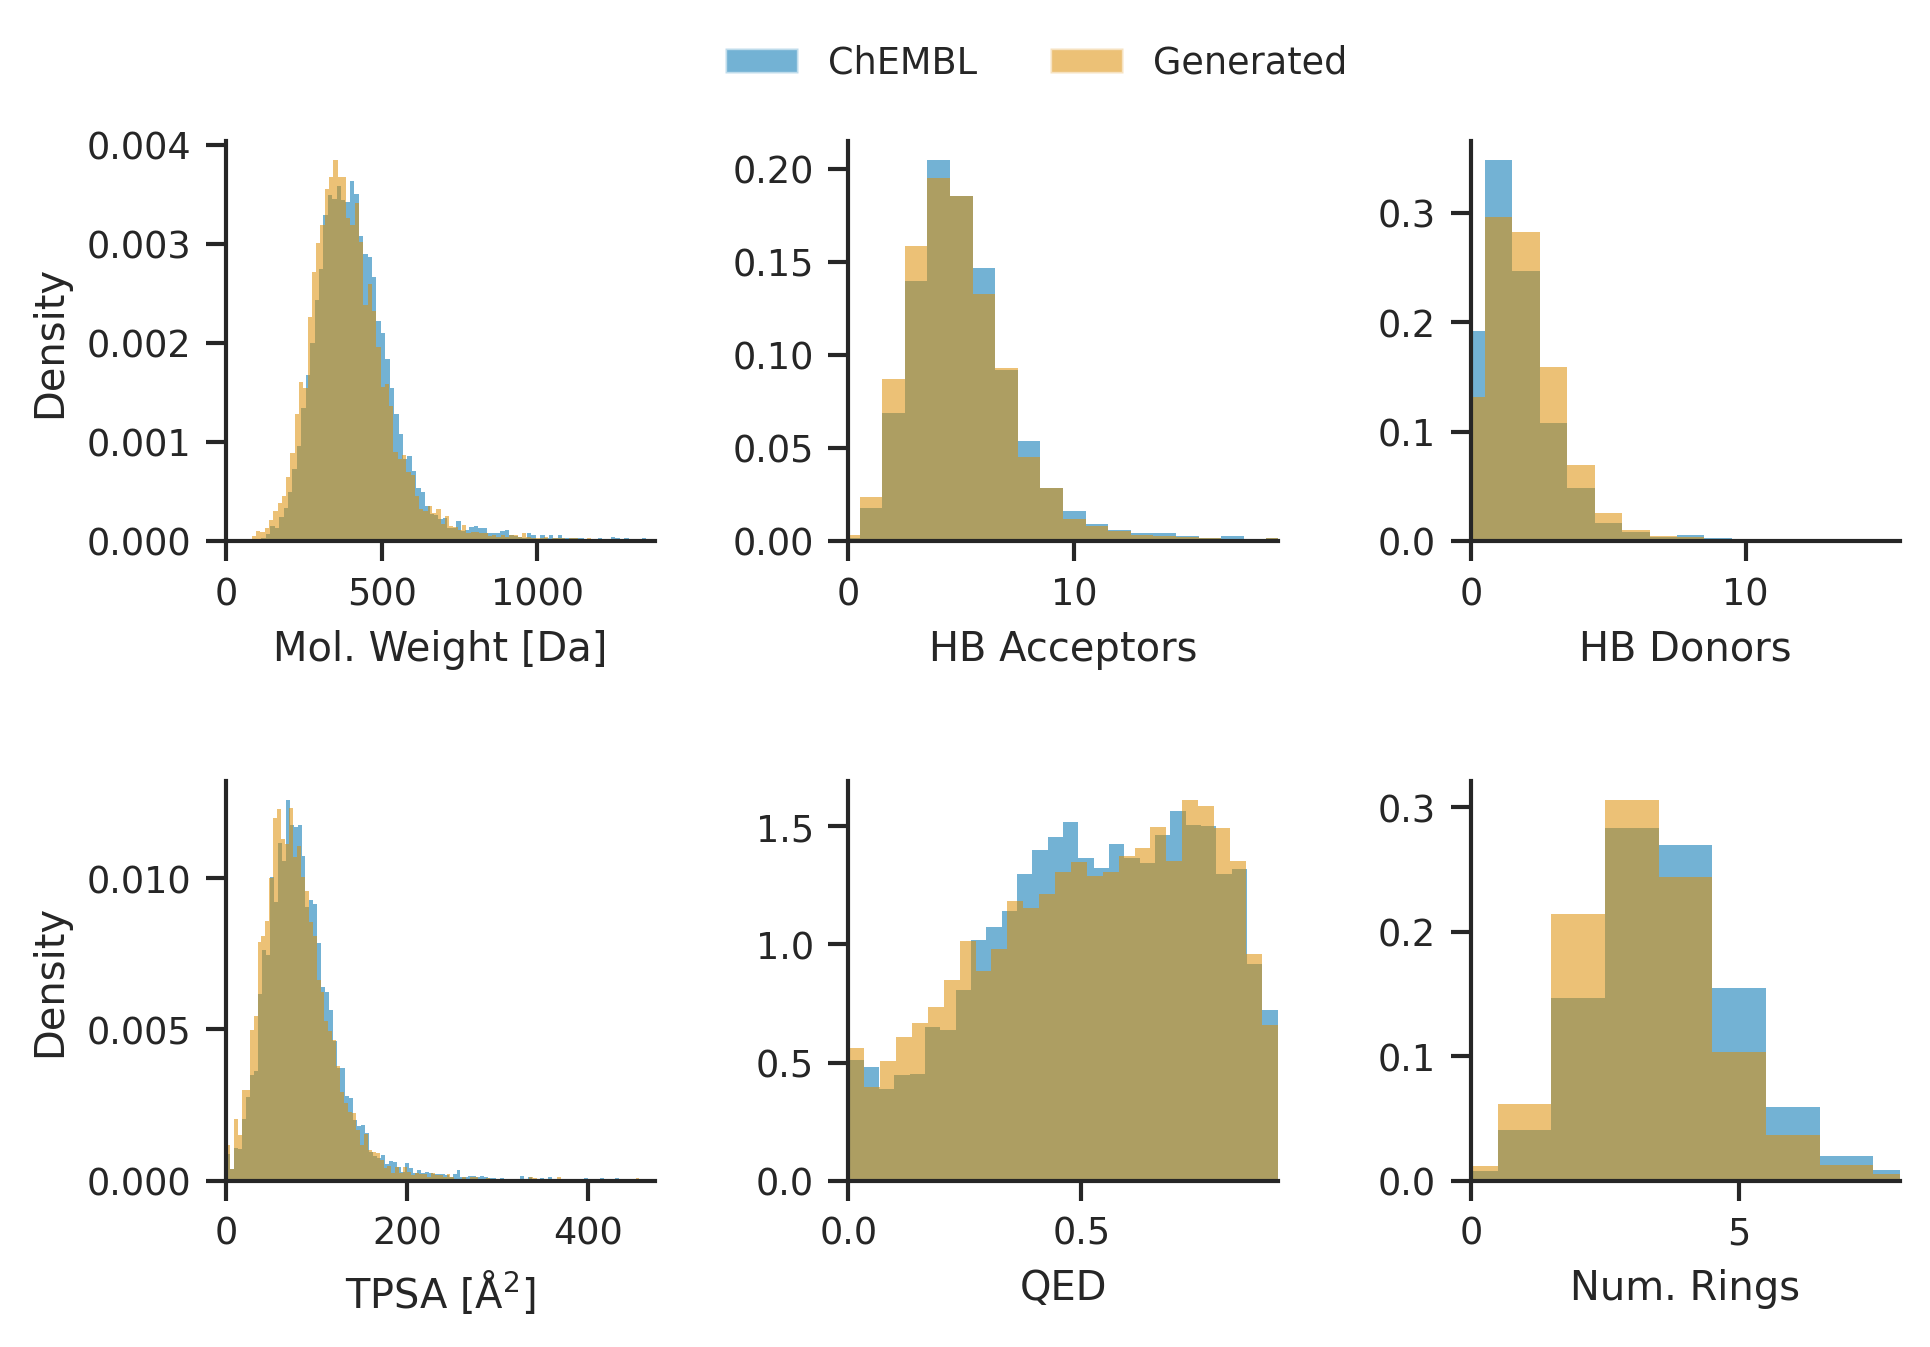

In [10]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

sns.set_theme(style="ticks", context="paper")

palette = sns.color_palette("colorblind")
labels = {
    'mw': 'Mol. Weight [Da]',
    'hba': 'HB Acceptors',
    'hbd': 'HB Donors',
    'tpsa': r'TPSA [Å$^2$]',
    'qed': 'QED',
    'rings': 'Num. Rings',
}
integer_keys = {'hba', 'hbd', 'rings'}

fig = plt.figure(figsize=(7.2, 4.5), dpi=300)
gs = GridSpec(2, 3, figure=fig, hspace=0.6, wspace=0.45)
axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
]

kw = dict(stat='density', kde=False, alpha=0.55, linewidth=0)
for i, (key, ax) in enumerate(zip(labels, axes)):
    combined = ref_stats[key] + gen_stats[key]
    xmax = np.percentile(combined, 99)
    extra = {'discrete': True} if key in integer_keys else {'binrange': (0, xmax)}
    sns.histplot(ref_stats[key], color=palette[0], ax=ax, **kw, **extra)
    sns.histplot(gen_stats[key], color=palette[1], ax=ax, **kw, **extra)
    ax.set_xlim(0, xmax)
    ax.set_xlabel(labels[key])
    ax.set_ylabel('Density' if i in (0, 3) else '')
    sns.despine(ax=ax)

legend_elements = [
    Patch(facecolor=palette[0], alpha=0.55, label='ChEMBL'),
    Patch(facecolor=palette[1], alpha=0.55, label='Generated'),
]
fig.legend(handles=legend_elements, loc='lower center',
           bbox_to_anchor=(0.5, 0.9), frameon=False, ncol=2)

plt.show()

In [40]:
generation_settings = {
    "temperature":1, "top_p":1, "max_len": 5
}

def recursive_generation(mols: list[str], steps=3, width=2):
    output = {}
    for mol in mols:
        mol = tokenizer.strip(mol)
        children = model.extend(mol, num=width, **generation_settings)
        if steps-1 > 0:
            output[sf.decoder(mol)] = recursive_generation(children, steps=steps-1)
        else:
            output[sf.decoder(mol)] = [sf.decoder(tokenizer.strip(c)) for c in children]
    return output

tree = recursive_generation(model.generate(num=1, **generation_settings), steps=3)
tree

{'CCCN': {'CCCNCC=C': {'CCCN1CC=CC=C1C': ['CCCN1CC=CC=C1CNCCN',
    'CCCN1CC=CC=C1CNC'],
   'CCCNCC=CC=CC=CC': ['CCCNCC=C1C=CC=CC1', 'CCCNCC=C1C=CC=CC1=CC']},
  'CCCN(C)CC': {'CCCN(C)CC=CNC': ['CCCN(C)CC=CN(C)C=O', 'CCCN(C)CC=CN(C)C/C'],
   'CCCN(C)CC(=N)N': ['CCCN(C)CC(=N)N(C)C#N', 'CCCN(C)CC(=N)N(C)OCC']}}}

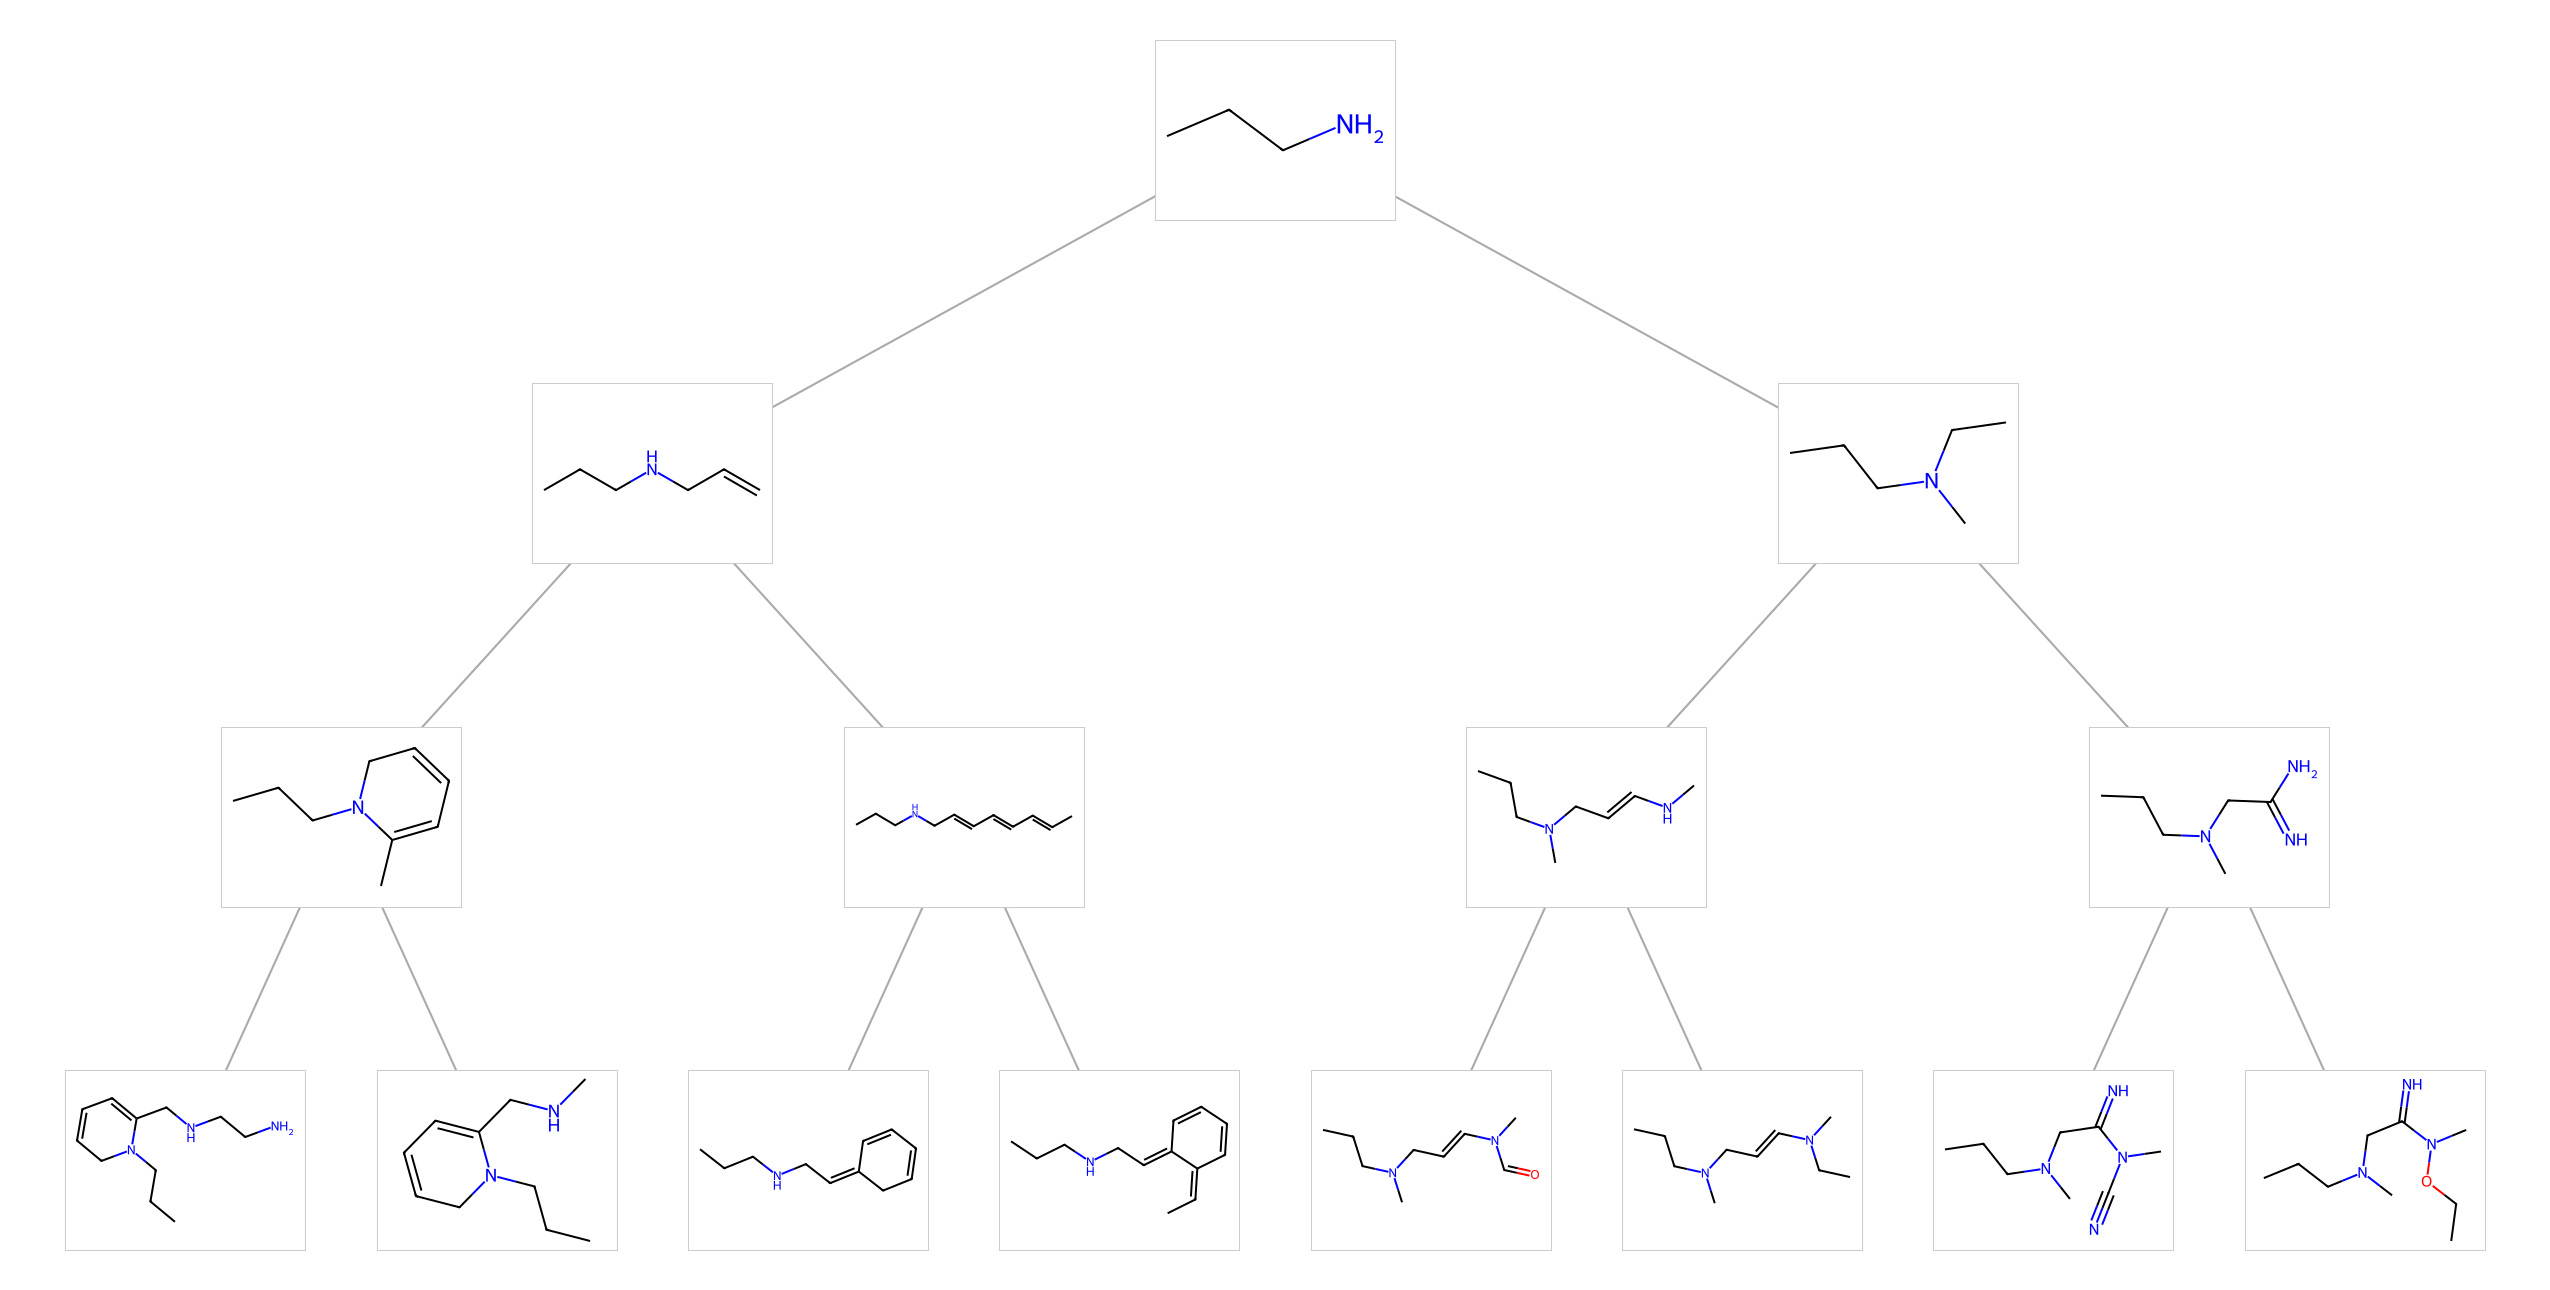

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from rdkit.Chem import Draw

MOL_SIZE = (240, 180)


def mol_image(smiles, parent_smiles=None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    if parent_smiles:
        pmol = Chem.MolFromSmiles(parent_smiles)
        if pmol:
            matches = mol.GetSubstructMatches(pmol)
            if matches:
                png = Draw.DrawMolWithMatches(mol, matches, molSize=MOL_SIZE)
                return PILImage.open(BytesIO(png))
    return Draw.MolToImage(mol, size=MOL_SIZE)


def parse_tree(tree):
    parent_map, children_map = {}, defaultdict(list)

    def _parse(subtree, parent):
        if isinstance(subtree, dict):
            for smi, val in subtree.items():
                parent_map[smi] = parent
                if parent is not None:
                    children_map[parent].append(smi)
                _parse(val, smi)
        else:
            for smi in subtree:
                parent_map[smi] = parent
                if parent is not None:
                    children_map[parent].append(smi)

    _parse(tree, None)
    return parent_map, children_map


def compute_positions(parent_map, children_map):
    roots = set(parent_map) - {s for s, p in parent_map.items() if p is not None}

    depth = {}
    q = deque((r, 0) for r in roots)
    while q:
        smi, d = q.popleft()
        depth[smi] = d
        for child in children_map.get(smi, []):
            q.append((child, d + 1))

    max_depth = max(depth.values())
    levels = defaultdict(list)
    for smi, d in depth.items():
        levels[d].append(smi)

    pos = {}
    for i, smi in enumerate(levels[max_depth]):
        pos[smi] = (float(i), float(max_depth))
    for d in range(max_depth - 1, -1, -1):
        for smi in levels[d]:
            ch = [c for c in children_map.get(smi, []) if c in pos]
            pos[smi] = (np.mean([pos[c][0] for c in ch]) if ch else 0.0, float(d))

    return pos, max_depth, levels


def draw_tree(tree):
    parent_map, children_map = parse_tree(tree)
    pos, max_depth, levels = compute_positions(parent_map, children_map)

    n_leaves = len(levels[max_depth])
    dpi = 150
    mol_inch_w = MOL_SIZE[0] / dpi
    mol_inch_h = MOL_SIZE[1] / dpi
    h_gap, v_gap = 0.5, 0.9

    fig_w = n_leaves * (mol_inch_w + h_gap)
    fig_h = (max_depth + 1) * (mol_inch_h + v_gap)
    mol_w = mol_inch_w / fig_w
    mol_h = mol_inch_h / fig_h

    x_vals = [p[0] for p in pos.values()]
    x_min, x_max = min(x_vals), max(x_vals)
    x_span = max(x_max - x_min, 1.0)
    pad_x = mol_w / 2 + 0.02
    pad_y = mol_h / 2 + 0.02

    def to_fig(x, y):
        fx = pad_x + (x - x_min) / x_span * (1 - 2 * pad_x)
        fy = (1 - pad_y) - y / max_depth * (1 - 2 * pad_y)
        return fx, fy

    fig = plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
    ax = fig.add_axes((0, 0, 1, 1), facecolor='white')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_zorder(0)

    for smi, parent in parent_map.items():
        if parent and parent in pos and smi in pos:
            x1, y1 = to_fig(*pos[parent])
            x2, y2 = to_fig(*pos[smi])
            ax.plot([x1, x2], [y1, y2], '-', color='#aaaaaa', lw=1.0, zorder=1)

    for smi, parent in parent_map.items():
        if smi not in pos:
            continue
        fx, fy = to_fig(*pos[smi])
        ax_mol = fig.add_axes((fx - mol_w / 2, fy - mol_h / 2, mol_w, mol_h))
        img = mol_image(smi)
        if img:
            ax_mol.imshow(img)
        ax_mol.set_xticks([])
        ax_mol.set_yticks([])
        for sp in ax_mol.spines.values():
            sp.set_linewidth(0.5)
            sp.set_edgecolor('#cccccc')
        ax_mol.set_zorder(10)

    plt.show()


draw_tree(tree)